# Step 1: Import libraries

In [2]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import  pandas as pd
import  numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read raw  data file
df=pd.read_csv("https://raw.githubusercontent.com/hitrangnek/customer-behavior-data-analyst/refs/heads/main/customer_shopping_behavior_raw_data.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
data=df.copy()
data.shape # Check the total rows and columns in the dataset

(3900, 18)

# Step 2: Data Preprocessing

In [6]:
data.isna().sum() #Check the null values

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
data.dtypes #Check the data types of each column

Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

In [8]:
data['Category'].value_counts() #Check the unique values in the Category column

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [9]:
#Filling the missing values in the Revwiew based on grouping data by catgory
def fill_missing_rating(group):
    median_rating = group.median()
    return group.fillna(median_rating)

data['Review Rating'] = (
    data.groupby('Category')['Review Rating']
      .transform(fill_missing_rating)
)

In [10]:
#checl null values after filling missing values
data.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [11]:
#rename the columns to easier to work with
data.columns=data.columns.str.lower() #lower case the columns names
data.columns=data.columns.str.replace(' ','_') #replace the space with dash
data = data.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [12]:
data.columns #check the columns names again 

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [13]:
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']

# Create a new column: age_group
data['age_group'] = pd.qcut(
    data['age'],
    q=4,
    labels=labels
)

# Display the first 10 rows
data[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [14]:
# Create a new column: purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

data['purchase_frequency_days'] = (
    data['frequency_of_purchases']
    .map(frequency_mapping)
)

# Display the first 10 rows
data[['purchase_frequency_days', 'frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [15]:
data[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [16]:
# Drop the promo_code_used column
data = data.drop('promo_code_used', axis=1)

# Display the remaining columns
data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

# Step 3: Exploratory Data Analysis (EDA)

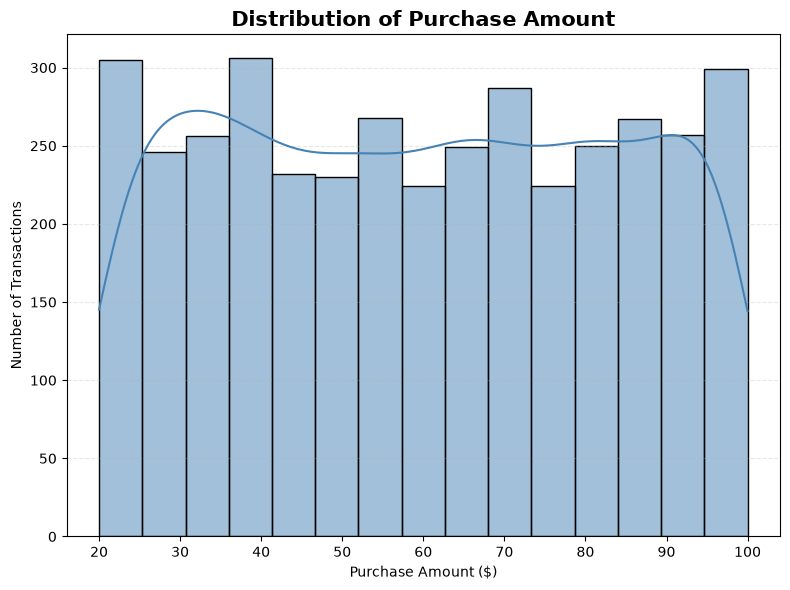

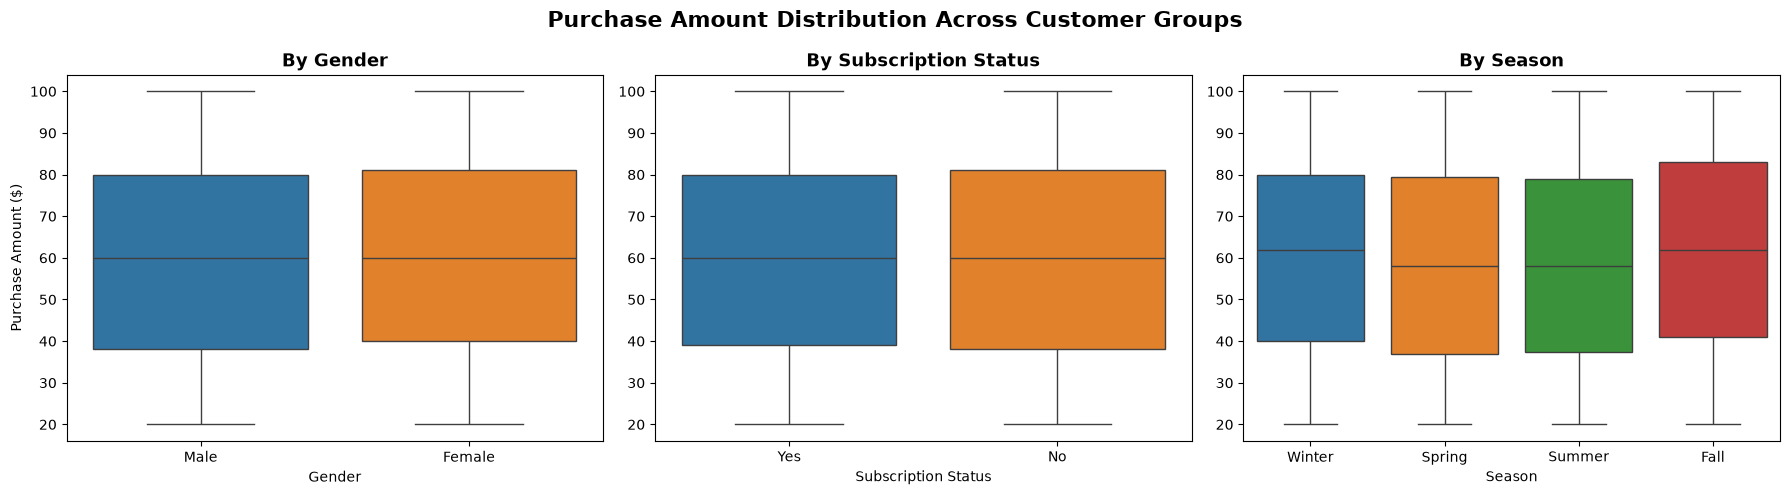

In [23]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=data,
    x='purchase_amount',
    bins=15,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Purchase Amount', fontsize=15, fontweight='bold')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Number of Transactions')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot 1: Purchase Amount by Gender
sns.boxplot(
    data=data,
    x='gender',
    y='purchase_amount',
    hue='gender',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('By Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Purchase Amount ($)')

# Boxplot 2: Purchase Amount by Subscription Status
sns.boxplot(
    data=data,
    x='subscription_status',
    y='purchase_amount',
    hue='subscription_status',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('By Subscription Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Subscription Status')
axes[1].set_ylabel('')

# Boxplot 3: Purchase Amount by Season
sns.boxplot(
    data=data,
    x='season',
    y='purchase_amount',
    hue='season',
    legend=False,
    ax=axes[2]
)
axes[2].set_title('By Season', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('')

# Main title
fig.suptitle(
    'Purchase Amount Distribution Across Customer Groups',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Insights
The boxplots indicate that purchase amount remains relatively consistent across customer groups. Gender, subscription status, and season all exhibit similar median purchase amounts and comparable spending variability. These findings suggest that these categorical variables are not strong drivers of transaction value within this dataset.

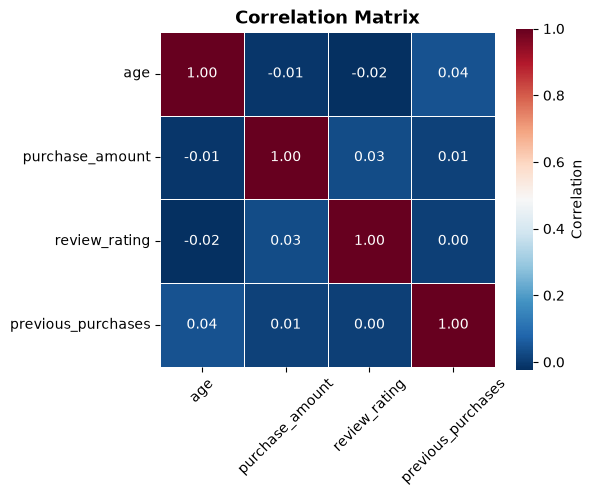

In [18]:
# Select numerical features
numeric_features = data[
    ['age',
     'purchase_amount',
     'review_rating',
     'previous_purchases']
]

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Create figure
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation'}
)

plt.title(
    'Correlation Matrix',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)

plt.tight_layout()
plt.show()

### Insights
All correlation coefficients between the numerical variables are very close to 0.

This indicates that there are no meaningful linear relationships among the variables in this dataset.

#### Download the final dataset after preprocessing

In [20]:
data.to_csv("final_data.csv", index=False)

# Connect to mySQL

# Install required libraries
!pip install pymysql sqlalchemy

In [ ]:
from sqlalchemy import create_engine
import pandas as pd

# MySQL connection
username = "root"
password = "your_password"
host = "localhost"
port = "3306"
database = "customer_behavior"

# Create connection engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Write DataFrame to MySQL
table_name = "final_data"

data.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

# Read back sample data
pd.read_sql(
    "SELECT * FROM final_data LIMIT 5;",
    engine
)